# Análisis de Ventas de una Tienda Online


##La empresa quiere aumentar sus ganancias. Para ello necesita comprender qué productos, categorías, regiones y clientes generan más rentabilidad, y cómo influyen factores como los descuentos y la **estacionalidad**

**2) IMPORTACION DE LIBRERIAS A UTILIZAR**

In [ ]:
import pandas as pd
import numpy as np
import plotly as plt
import matplotlib.pyplot as plt
print("Librerias importadas..")

Librerias importadas..


**3) CARGA DEL DATASET**

In [ ]:
df=pd.read_csv("/content/samplesuperstore.csv")
print("csv importado..")
df = df.rename(columns={
    "Row ID": "ID_Fila",
    "Order ID": "ID_Pedido",
    "Order Date": "Fecha_Pedido",
    "Ship Date": "Fecha_Envio",
    "Ship Mode": "Modo_Envio",
    "Customer ID": "ID_Cliente",
    "Customer Name": "Nombre_Cliente",
    "Segment": "Segmento",
    "Country/Region": "Pais",
    "City": "Ciudad",
    "State/Province": "Provincia",
    "Postal Code": "Codigo_Postal",
    "Region": "Region",
    "Product ID": "ID_Producto",
    "Category": "Categoria",
    "Sub-Category": "Subcategoria",
    "Product Name": "Nombre_Producto",
    "Sales": "Ventas",
    "Quantity": "Cantidad",
    "Discount": "Descuento",
    "Profit": "Ganancia"
})

csv importado..


**4) EXPLORACION INICIAL**

In [ ]:
print("Primeras filas:")
display(df.head())

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())


Primeras filas:


,ID_Fila,ID_Pedido,Fecha_Pedido,Fecha_Envio,Modo_Envio,ID_Cliente,Nombre_Cliente,Segmento,Pais,Ciudad,...,Codigo_Postal,Region,ID_Producto,Categoria,Subcategoria,Nombre_Producto,Ventas,Cantidad,Descuento,Ganancia
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


Filas: 4600
Columnas: 21

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Fila          4600 non-null   int64  
 1   ID_Pedido        4600 non-null   object 
 2   Fecha_Pedido     4600 non-null   object 
 3   Fecha_Envio      4600 non-null   object 
 4   Modo_Envio       4600 non-null   object 
 5   ID_Cliente       4600 non-null   object 
 6   Nombre_Cliente   4600 non-null   object 
 7   Segmento         4600 non-null   object 
 8   Pais             4600 non-null   object 
 9   Ciudad           4600 non-null   object 
 10  Provincia        4600 non-null   object 
 11  Codigo_Postal    4600 non-null   object 
 12  Region           4600 non-null   object 
 13  ID_Producto      4600 non-null   object 
 14  Categoria        4600 non-null   object 
 15  Subcategoria     4600 non-null   object 
 16  Nombre_Pr

,ID_Fila,Ventas,Cantidad,Descuento,Ganancia
count,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,2300.500000,234.242688,3.796739,0.154352,27.377198
std,1328.049949,624.026146,2.233828,0.205971,193.601819
min,1.000000,0.852000,1.000000,0.000000,-3701.892800
25%,1150.750000,17.407500,2.000000,0.000000,1.678200
50%,2300.500000,56.300000,3.000000,0.150000,8.878400
75%,3450.250000,216.660000,5.000000,0.200000,31.216900
max,4600.000000,22638.480000,14.000000,0.800000,4630.475500


**5) LIMPIEZA DE DATOS**

In [ ]:
#Volvemos a verificar si efectivamente no hay datos nulos en el Documento
print("Valores nulos: ")
display(df.isnull().sum())
print()
#Verificamos que no haya ninguna fila duplicadas
print("Cantidad de filas duplicadas:  ")
display(df.duplicated().sum())
#Reconvercion de tipo de datos: Se encontro que la columna Fecha_pedido,Fecha_envio Se clasificaban como tipo de dato Object,Se cambia su tipo de dato  a DateTime.
df['Fecha_Pedido'] = pd.to_datetime(df['Fecha_Pedido'])
df['Fecha_Envio'] = pd.to_datetime(df['Fecha_Envio'])
df['Año']=df['Fecha_Pedido'].dt.year
df['Mes']=df['Fecha_Pedido'].dt.month

print()
print("Columnas modificadas correctamente")




Valores nulos: 


,0
ID_Fila,0
ID_Pedido,0
Fecha_Pedido,0
Fecha_Envio,0
Modo_Envio,0
ID_Cliente,0
Nombre_Cliente,0
Segmento,0
Pais,0
Ciudad,0



Cantidad de filas duplicadas:  


np.int64(0)


Columnas modificadas correctamente


6) EXPLORACION Y ANALISIS DE DATOS


1) KPIs generales


Calcular:

Ventas totales.
Ganancia total.
Cantidad de pedidos.
Cantidad de clientes únicos.
Ticket promedio

In [30]:
print(f"Ventas totales: ${df['Ventas'].sum():,.2f}")
print(f"Ganancia total: ${df['Ganancia'].sum():,.2f}")
print("Las cantidades de pedidos  totales fueron de :  ",df['ID_Pedido'].count())
print("La cantidad de clientes unicos fueron de :  ",df['ID_Cliente'].nunique())
print("El ticket promedio fue de :  ",df['Ventas'].mean())






Ventas totales: $1,077,516.37
Ganancia total: $125,935.11
Las cantidades de pedidos  totales fueron de :   4600
La cantidad de clientes unicos fueron de :   753
El ticket promedio fue de :   234.2426880652174


 2) Análisis por categoría

Preguntas:

¿Qué categoría vende más?
¿Cuál genera más ganancias?

Categorías con mayores ventas:
Categoria
Technology         384661.6300
Furniture          366534.2371
Office Supplies    326320.4980
Name: Ventas, dtype: float64

Categorias con mayores Ganancias
Categoria
Technology         64313.2676
Office Supplies    51222.2451
Furniture          10399.5967
Name: Ganancia, dtype: float64


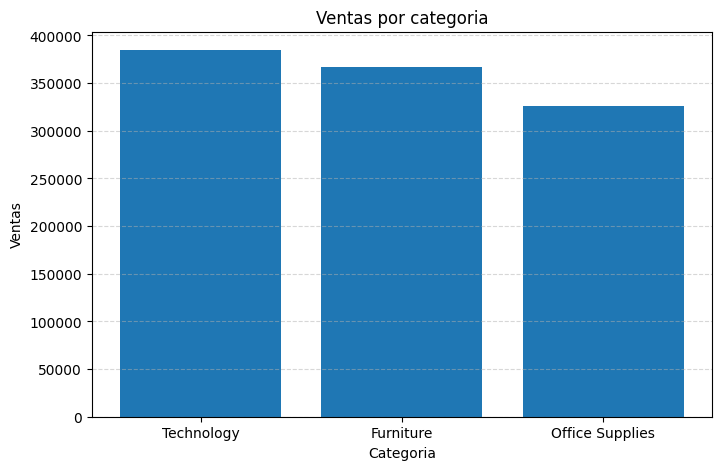

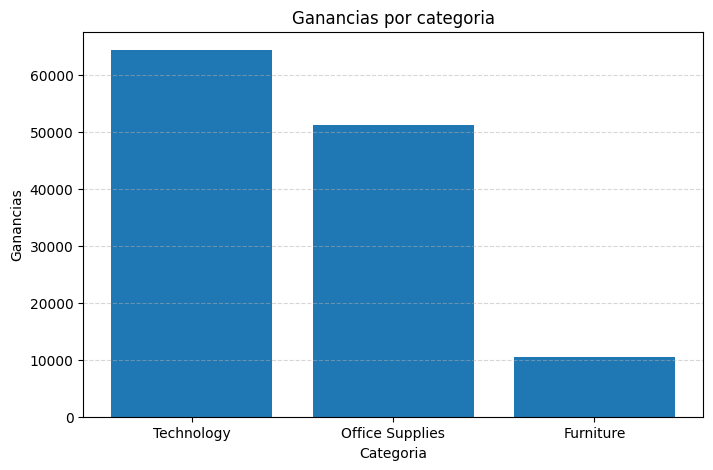

In [ ]:
ventas_por_categoria = df.groupby('Categoria')['Ventas'].sum().sort_values(ascending=False)
print("Categorías con mayores ventas:")
print(ventas_por_categoria)

print()

ganancias_por_categorias=df.groupby('Categoria')['Ganancia'].sum().sort_values(ascending=False)
print("Categorias con mayores Ganancias")
print(ganancias_por_categorias)


#Ventas por categoria grafico
plt.figure(figsize=(8,5))
plt.bar(ventas_por_categoria.index,ventas_por_categoria.values)
plt.title("Ventas por categoria")
plt.xlabel("Categoria")
plt.ylabel("Ventas")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()
print()


#Ganancias por categoria grafico
plt.figure(figsize=(8,5))
plt.bar(ganancias_por_categorias.index,ganancias_por_categorias.values)
plt.title("Ganancias por categoria")
plt.xlabel("Categoria")
plt.ylabel("Ganancias")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()




3) Análisis por subcategoría

Las sillas venden mucho pero dejan poca ganancia.
El papel deja muy buena rentabilidad.

Subcategorias con mayores ventas:
Subcategoria
Chairs         167280.0690
Phones         165446.6580
Machines       107874.7600
Storage        105556.3740
Tables          93760.5900
Binders         87752.5420
Accessories     70951.0560
Bookcases       63524.1841
Appliances      42389.7220
Furnishings     41969.3940
Name: Ventas, dtype: float64

Subcategorias con mayores ganancias:
Subcategoria
Phones         24414.6932
Accessories    17738.5301
Chairs         14700.3503
Paper          14495.5685
Copiers        13806.2206
Binders        12175.9409
Storage         8828.3456
Machines        8353.8237
Furnishings     6366.1770
Appliances      5627.5767
Name: Ganancia, dtype: float64

Subcategorias con mayores perdidas:
Subcategoria
Tables        -7451.1789
Bookcases     -3215.7517
Supplies       -245.0170
Fasteners       468.4829
Labels         2681.3149
Art            3222.6216
Envelopes      3967.4110
Appliances     5627.5767
Furnishings    6366.1770
Machines       8353.8237
Name: Gananc

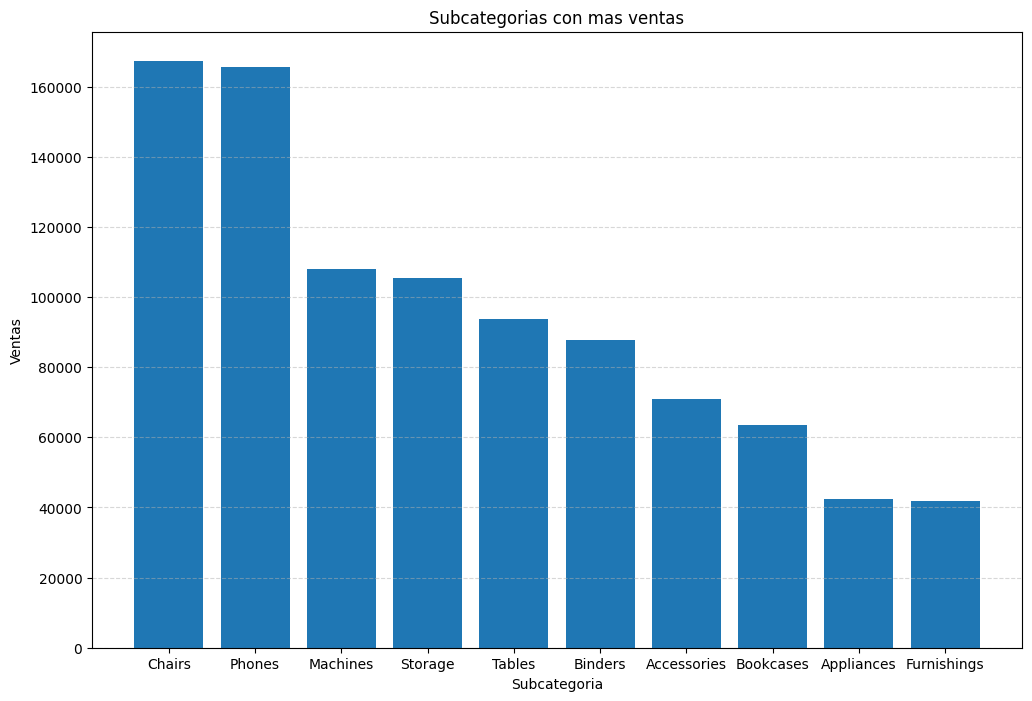

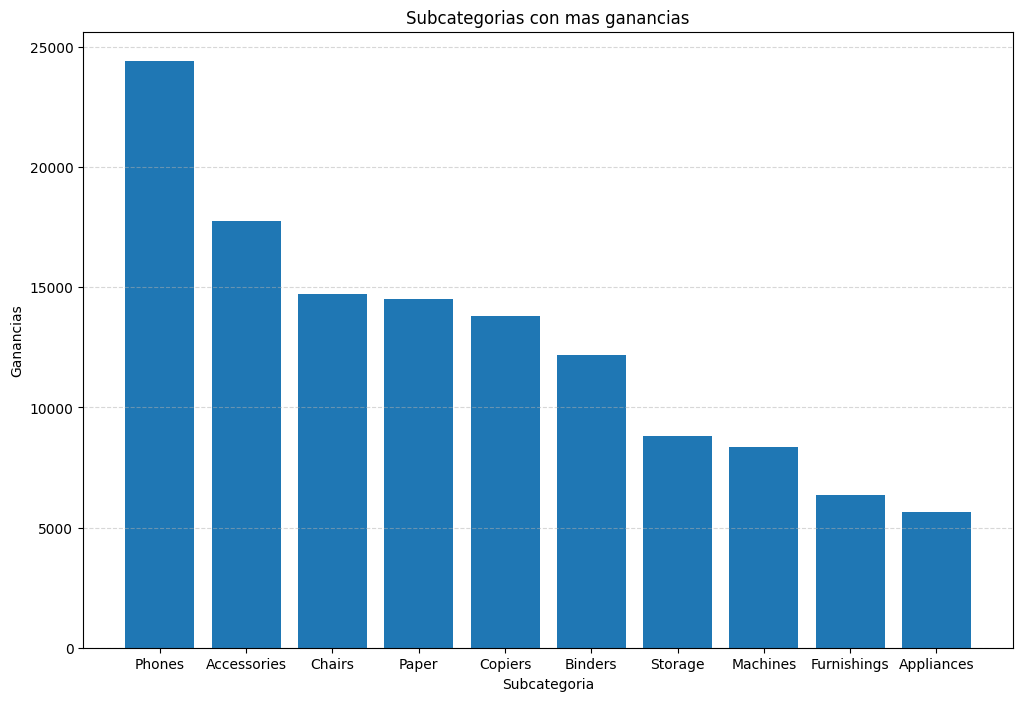

In [ ]:
subcategorias_ventas=df.groupby('Subcategoria')['Ventas'].sum().sort_values(ascending=False).head(10)
print("Subcategorias con mayores ventas:")
print(subcategorias_ventas)

print()

subcategorias_ganancias=df.groupby('Subcategoria')['Ganancia'].sum().sort_values(ascending=False).head(10)
print("Subcategorias con mayores ganancias:")
print(subcategorias_ganancias)
print()

subcategorias_perdidas=df.groupby('Subcategoria')['Ganancia'].sum().sort_values(ascending=True).head(10)
print("Subcategorias con mayores perdidas:")
print(subcategorias_perdidas)
print()

#Grafico subcategorias con mas ventas
plt.figure(figsize=(12,8))
plt.bar(subcategorias_ventas.index,subcategorias_ventas.values)
plt.title("Subcategorias con mas ventas")
plt.xlabel("Subcategoria")
plt.ylabel("Ventas")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()
print()
#Grafico subcategorias con mas ganancias
plt.figure(figsize=(12,8))
plt.bar(subcategorias_ganancias.index,subcategorias_ganancias.values)
plt.title("Subcategorias con mas ganancias")
plt.xlabel("Subcategoria")
plt.ylabel("Ganancias")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.show()






4. Análisis temporal
Ventas por mes.
Ganancias por mes.

Ventas por mes:  
Mes
1      51810.3016
2      39450.1180
3     149943.6060
4      78133.4605
5      56566.7135
6      59466.7716
7      62711.7180
8      65975.3427
9     147297.4748
10     63820.4725
11    154799.5202
12    147540.8657
Name: Ventas, dtype: float64

Ganancias por mes:  
Mes
11    21837.7441
12    17647.7198
9     16813.6553
3     14331.9495
8     11136.8524
2      8680.7387
6      8335.3166
4      8277.6866
5      7873.5288
10     6287.1409
7      2447.1657
1      2265.6110
Name: Ganancia, dtype: float64



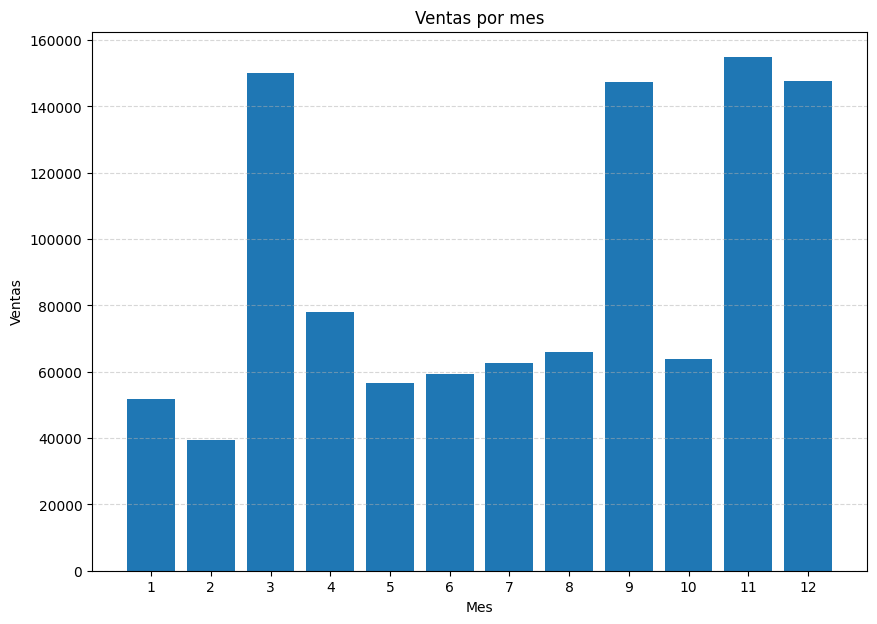

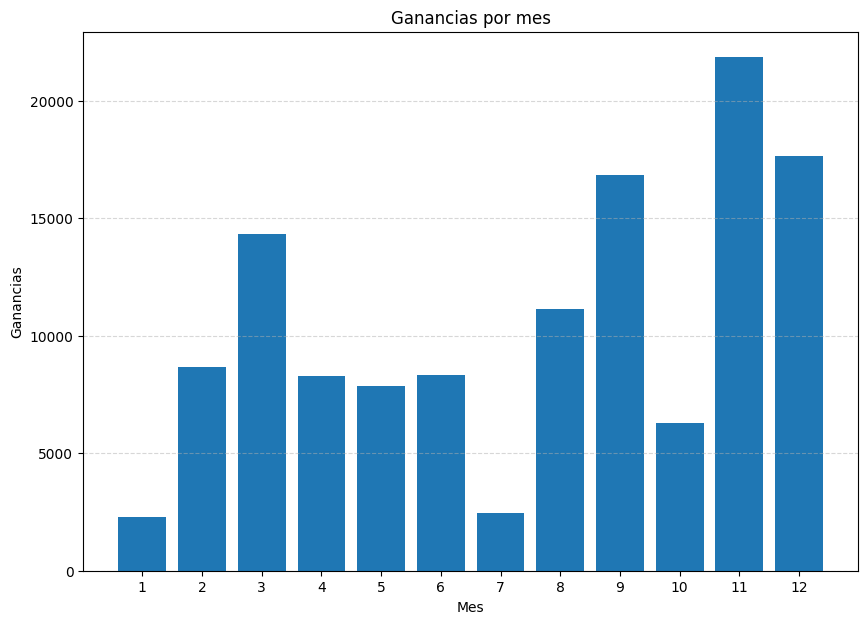

In [ ]:
ventas_mes=df.groupby('Mes')['Ventas'].sum()
print("Ventas por mes:  ")
print(ventas_mes)

print()

ganancias_mes=df.groupby('Mes')['Ganancia'].sum().sort_values(ascending=False)
print("Ganancias por mes:  ")
print(ganancias_mes)
print()
#Grafico ventas por mes
plt.figure(figsize=(10,7))
plt.bar(ventas_mes.index,ventas_mes.values)
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.xticks(range(1,13))
plt.show()
print()

#Grafico ganancias por mes
plt.figure(figsize=(10,7))
plt.bar(ganancias_mes.index,ganancias_mes.values)
plt.title("Ganancias por mes")
plt.xlabel("Mes")
plt.ylabel("Ganancias")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.xticks(range(1,13))
plt.show()

5. Análisis geográfico
Ventas por región.
Ganancias por región.

La region con mas ventas ha sido:  
Region
East       324158.7550
West       321950.6465
Central    231045.1456
South      200361.8180
Name: Ventas, dtype: float64

La region con mas ganancias ha sido:  
Region
East       44867.8644
West       44036.1074
South      26156.8318
Central    10874.3058
Name: Ganancia, dtype: float64


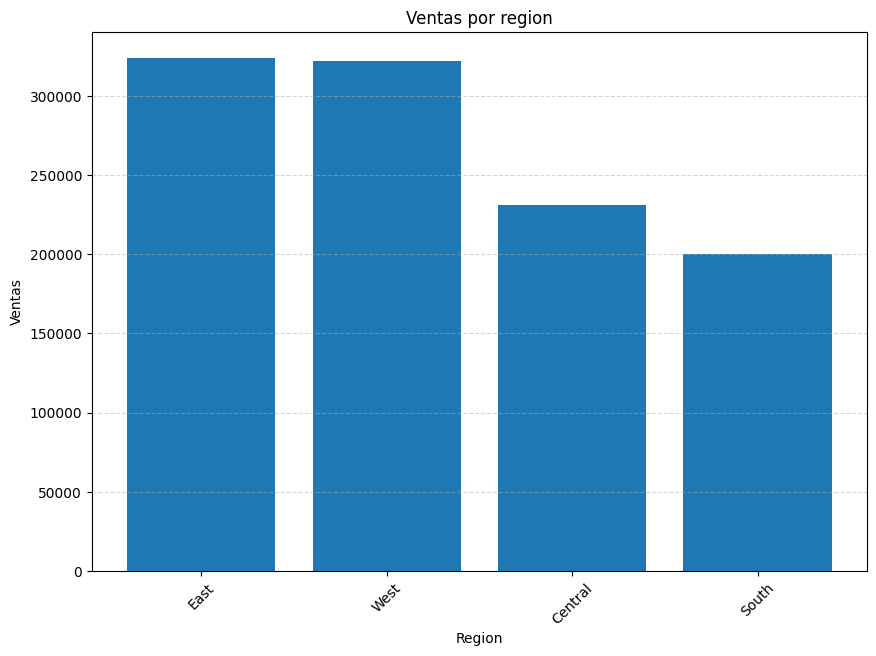

In [28]:
ventas_region=df.groupby('Region')['Ventas'].sum().sort_values(ascending=False)
print("La region con mas ventas ha sido:  ")
print(ventas_region)

print()

ganancias_region=df.groupby('Region')['Ganancia'].sum().sort_values(ascending=False)
print("La region con mas ganancias ha sido:  ")
print(ganancias_region)

#Grafico ventas por region
plt.figure(figsize=(10,7))
plt.bar(ventas_region.index,ventas_region.values)
plt.title("Ventas por region")
plt.xlabel("Region")
plt.ylabel("Ventas")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.xticks(rotation=45)
plt.show()

6. Clientes
Clientes que más compran.
Clientes que más ganancias generan.




Los clientes con mas compras son:  
Nombre_Cliente
Sean Miller         24508.632
Sanjit Chand        13132.830
Becky Martin        10539.896
Ken Lonsdale         9608.142
Sanjit Engle         9589.500
Greg Tran            9420.246
Peter Fuller         9062.864
Tom Boeckenhauer     8162.510
Karen Daniels        8091.018
Zuschuss Carroll     7798.641
Name: Ventas, dtype: float64

Los clientes que mas ganancias dejan son :  
Nombre_Cliente
Sanjit Chand            5555.2653
Christopher Martinez    3197.4580
Sanjit Engle            3039.0106
Keith Dawkins           2845.0455
Nathan Mautz            2747.3349
                          ...    
Natalie Fritzler       -1793.6420
Becky Martin           -1878.7892
Sean Miller            -2015.0155
Christine Phan         -2076.1254
Luke Foster            -3655.8681
Name: Ganancia, Length: 753, dtype: float64



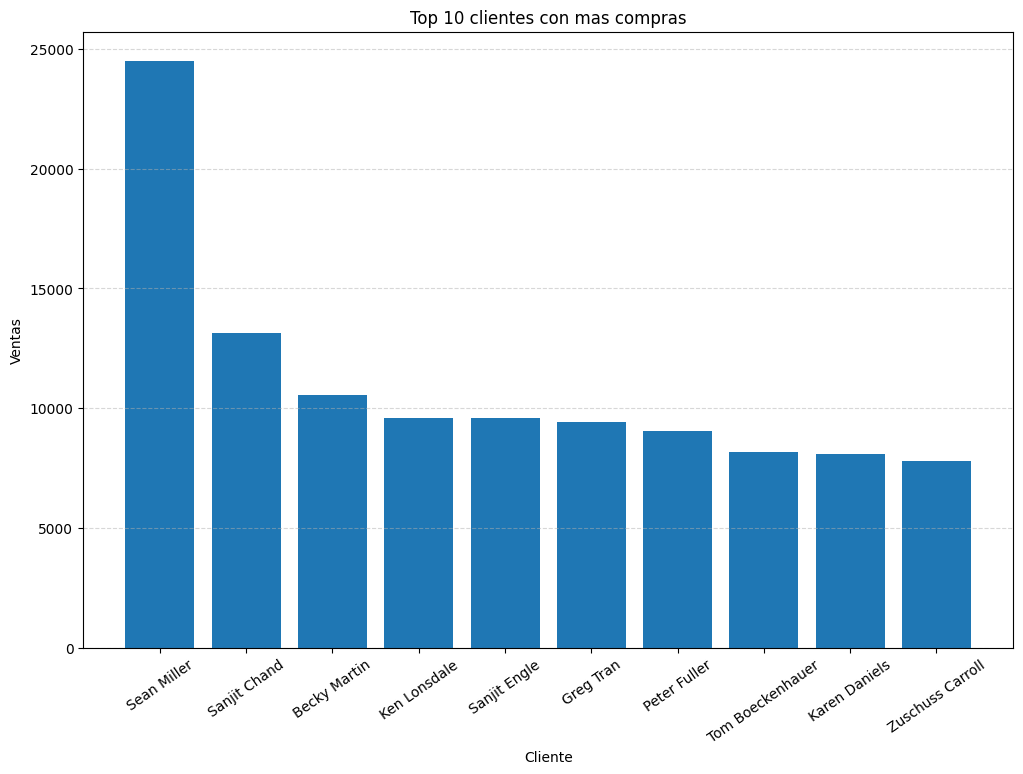

In [ ]:
ventas_clientes=df.groupby('Nombre_Cliente')['Ventas'].sum().sort_values(ascending=False).head(10)
print("Los clientes con mas compras son:  ")
print(ventas_clientes)
print()
ganancias_clientes=df.groupby('Nombre_Cliente')['Ganancia'].sum().sort_values(ascending=False)
print("Los clientes que mas ganancias dejan son :  ")
print(ganancias_clientes)
print()
#Grafico top 10 clientes
plt.figure(figsize=(12,8))
plt.bar(ventas_clientes.index,ventas_clientes.values)
plt.title("Top 10 clientes con mas compras")
plt.xlabel("Cliente")
plt.ylabel("Ventas")
plt.grid(axis="y",linestyle="--",alpha=0.5)
plt.xticks(rotation=35)
plt.show()

 7) Descuentos

 El análisis evidencia una relación clara entre el nivel de descuento y la rentabilidad. Las ventas con descuentos de hasta el 20% continúan siendo rentables. Sin embargo, a partir de descuentos del 30% las operaciones comienzan a generar pérdidas, las cuales se incrementan considerablemente con descuentos del 70% y 80%. Esto sugiere que la política de descuentos debería revisarse para evitar comprometer la rentabilidad de la empresa.

Frecuencia de cada descuento:
Descuento
0.00    2237
0.10      48
0.15      26
0.20    1646
0.30     113
0.32      11
0.40      96
0.45       4
0.50      32
0.60      65
0.70     181
0.80     141
Name: count, dtype: int64

Porcentaje de ventas en cada descuento:
Descuento
0.00    48.63
0.10     1.04
0.15     0.57
0.20    35.78
0.30     2.46
0.32     0.24
0.40     2.09
0.45     0.09
0.50     0.70
0.60     1.41
0.70     3.93
0.80     3.07
Name: proportion, dtype: float64

Los descuentos que generan perdidas son:  
Descuento
0.70    -15812.5850
0.80    -14979.6693
0.40    -12832.7567
0.50    -10574.5681
0.30     -4744.5272
0.60     -2085.1873
0.32      -940.6929
0.45      -727.4112
0.15       321.2222
0.10      4327.9973
0.20     38595.4796
0.00    145387.8080
Name: Ganancia, dtype: float64

Los descuentos que generan ganancias son:  
Descuento
0.00    145387.8080
0.20     38595.4796
0.10      4327.9973
0.15       321.2222
0.45      -727.4112
0.32      -940.6929
0.60     -2085.1873
0.30  

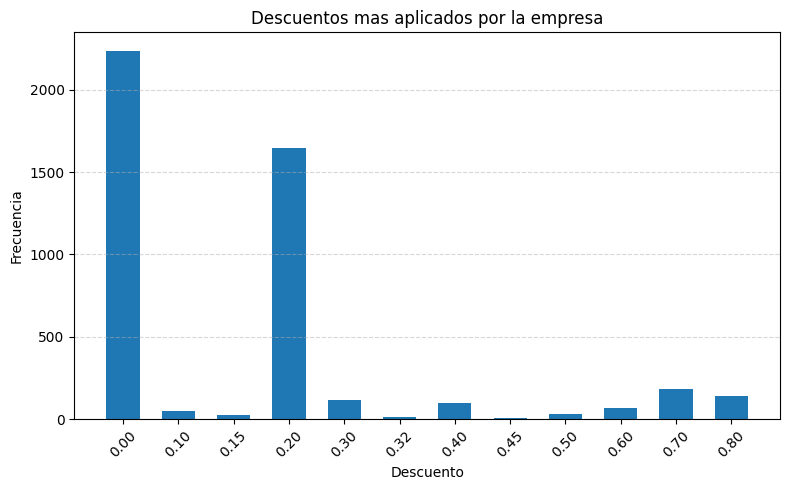

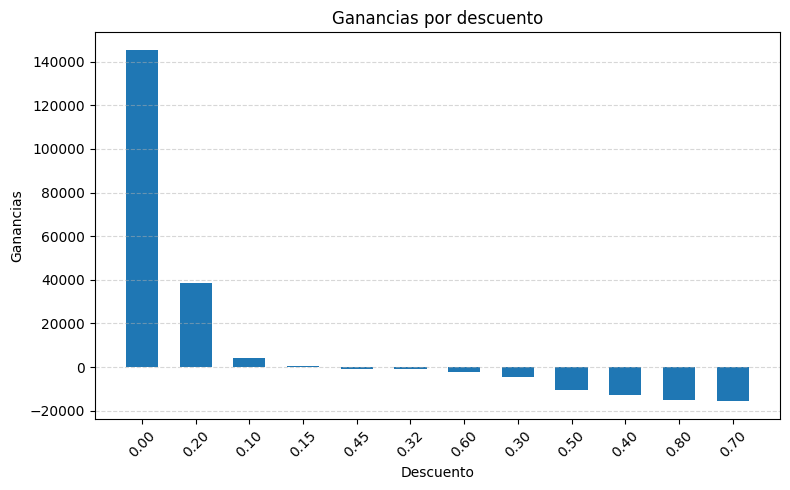

In [ ]:
#Descuentos Mas Utilizados
descuentos_frecuentes = df["Descuento"].value_counts().sort_index()
print("Frecuencia de cada descuento:")
print(descuentos_frecuentes)
print()
#Porcentaje de ventas en cada descuento
porcentaje_descuentos = df["Descuento"].value_counts(normalize=True).sort_index() * 100
print("Porcentaje de ventas en cada descuento:")
print(porcentaje_descuentos.round(2))
print()

#Descuentos que mas perdidas generaron
descuentos_perdidas=df.groupby('Descuento')['Ganancia'].sum().sort_values(ascending=True)
print("Los descuentos que generan perdidas son:  ")
print(descuentos_perdidas)
print()
descuentos_ganancias=df.groupby('Descuento')['Ganancia'].sum().sort_values(ascending=False)
print("Los descuentos que generan ganancias son:  ")
print(descuentos_ganancias)
print()

#GRAFICO
#Descuentos y sus ventas
plt.figure(figsize=(8,5))
plt.bar(range(len(descuentos_frecuentes)), descuentos_frecuentes.values, width=0.6)
plt.xticks(range(len(descuentos_frecuentes)), [f"{x:.2f}" for x in descuentos_frecuentes.index], rotation=45)
plt.title("Descuentos mas aplicados por la empresa")
plt.xlabel("Descuento")
plt.ylabel("Frecuencia")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print()



# Grafico Ganancias por descuento
plt.figure(figsize=(8,5))
plt.bar(range(len(descuentos_ganancias)), descuentos_ganancias.values, width=0.6)
plt.xticks(range(len(descuentos_ganancias)), [f"{x:.2f}" for x in descuentos_ganancias.index], rotation=45)
plt.title("Ganancias por descuento")
plt.xlabel("Descuento")
plt.ylabel("Ganancias")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


8 Ventas Con Perdidas

In [27]:
ventas_perdidas2 = (df['Ganancia'] < 0).sum()
print("Cantidad de ventas con perdidas:  ")
print(ventas_perdidas2)
print()

#Categorias con mas perdidas
perdidas_categoria=df.groupby('Categoria')['Ganancia'].sum().sort_values(ascending=True)
print("Las categorias con mas perdidas son:  ")
print(perdidas_categoria)
print()
#Subcategorias con mas perdidas
subcategorias_perdidas2=df.groupby('Subcategoria')['Ganancia'].sum().sort_values(ascending=True)
print("Las subcategorias con mas perdidas son:  ")
print(subcategorias_perdidas2)
print()

#Regiones con mas perdidas
regiones_perdidas=df.groupby('Region')['Ganancia'].sum().sort_values(ascending=True)
print("Las regiones con mas perdidas son :  ")
print(regiones_perdidas)
print()

#Productos con mas ventas(top 10)
productos_mas_vendidos=df.groupby('Nombre_Producto')['Ventas'].sum().sort_values(ascending=False).head(10)
print("Los 10  productos con mas ventas son:  ")
print(productos_mas_vendidos)
print()


#Porductos que generan mayores ganancias (top 10)
productos_perdidas=df.groupby('Nombre_Producto')['Ganancia'].sum().sort_values(ascending=False).head(10)
print("Los 10 productos con mas ganancias son.  ")
print(productos_perdidas)
print()




Cantidad de ventas con perdidas:  
864

Las categorias con mas perdidas son:  
Categoria
Furniture          10399.5967
Office Supplies    51222.2451
Technology         64313.2676
Name: Ganancia, dtype: float64

Las subcategorias con mas perdidas son:  
Subcategoria
Tables         -7451.1789
Bookcases      -3215.7517
Supplies        -245.0170
Fasteners        468.4829
Labels          2681.3149
Art             3222.6216
Envelopes       3967.4110
Appliances      5627.5767
Furnishings     6366.1770
Machines        8353.8237
Storage         8828.3456
Binders        12175.9409
Copiers        13806.2206
Paper          14495.5685
Chairs         14700.3503
Accessories    17738.5301
Phones         24414.6932
Name: Ganancia, dtype: float64

Las regiones con mas perdidas son :  
Region
Central    10874.3058
South      26156.8318
West       44036.1074
East       44867.8644
Name: Ganancia, dtype: float64

Los 10  productos con mas ventas son:  
Nombre_Producto
Cisco TelePresence System EX90 Videocon

## 📌 Conclusiones

El análisis permitió identificar los principales factores que influyen en las ventas y la rentabilidad de la empresa a partir de un conjunto de más de 10.000 registros.
Se observó que las categorías y subcategorías con mayores ventas no siempre son las que generan mayores ganancias, lo que demuestra que un alto volumen de ventas no garantiza una mayor rentabilidad.
Se identificaron 1.901 ventas con ganancias negativas, representando aproximadamente el 18,6% del total de las transacciones.
Los descuentos fueron un factor determinante en la rentabilidad. Mientras que los descuentos de hasta el 20% mantuvieron ganancias positivas, a partir del 30% comenzaron a registrarse pérdidas significativas.
Los descuentos del 70% y 80% fueron los que acumularon las mayores pérdidas, lo que evidencia la necesidad de revisar la política comercial aplicada.
También se detectaron clientes con un elevado volumen de compras, pero con una contribución relativamente baja a la ganancia, indicando que el volumen de ventas debe analizarse junto con la rentabilidad.
Finalmente, el análisis permitió identificar categorías, subcategorías, regiones y productos que concentran la mayor cantidad de pérdidas, proporcionando información útil para la toma de decisiones.

## Recomendaciones

## 💡 Recomendaciones

1. **Revisar la política de descuentos**: Limitar los descuentos máximos al 20%, ya que a partir del 30% las operaciones generan pérdidas. Eliminar los descuentos del 70% y 80% que acumulan las mayores pérdidas.

2. **Enfocar esfuerzos en subcategorías rentables**: Priorizar las subcategorías con mayor margen de ganancia por sobre las de alto volumen pero baja rentabilidad.

3. **Analizar clientes de alto volumen y baja ganancia**: Revisar las condiciones comerciales de clientes que compran mucho pero aportan poco margen, y evaluar si es conveniente mantener esas condiciones.

4. **Aprovechar la estacionalidad**: Reforzar stock y campañas en los meses de mayor demanda identificados en el análisis temporal.

5. **Focalizar en la región más rentable**: Destinar mayores recursos comerciales a la región con mejor relación ventas/ganancia.